In [3]:
cd ~/Downloads/milk10k-skin-lesion-classification-main

/Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from scipy import ndimage

DATA_DIR = Path("data/milk10k")
IMAGE_DIR = DATA_DIR / "images"

df = pd.read_csv("lesion_table.csv")

print(df["diagnosis_1"].value_counts())
print(df[["lesion_id", "derm_id", "diagnosis_1"]].head())

diagnosis_1
Malignant        3634
Benign           1483
Indeterminate     123
Name: count, dtype: int64
    lesion_id       derm_id diagnosis_1
0  IL_0000652  ISIC_4671410   Malignant
1  IL_0003176  ISIC_5371928   Malignant
2  IL_0004688  ISIC_3624913   Malignant
3  IL_0005081  ISIC_5186409   Malignant
4  IL_0006177  ISIC_1048297   Malignant


In [8]:
# Select two examples from each of the main diagnosis classes
selected = pd.concat([
    df[df["diagnosis_1"] == "Benign"].head(2),
    df[df["diagnosis_1"] == "Malignant"].head(2)
]).reset_index(drop=True)

selected[["lesion_id", "derm_id", "diagnosis_1"]]

,lesion_id,derm_id,diagnosis_1
0,IL_0008891,ISIC_5916190,Benign
1,IL_0017483,ISIC_1225678,Benign
2,IL_0000652,ISIC_4671410,Malignant
3,IL_0003176,ISIC_5371928,Malignant


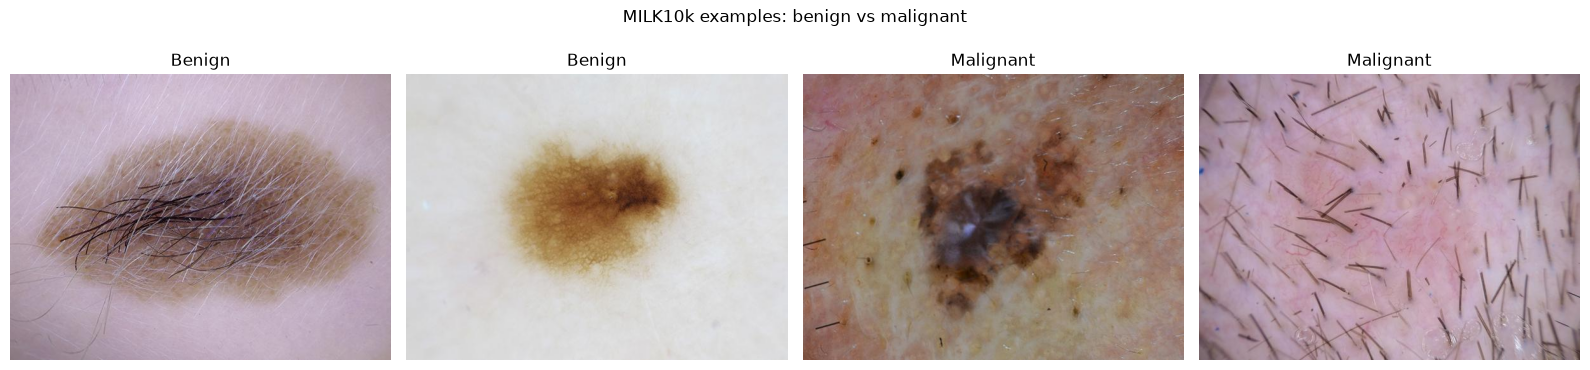

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (_, row) in zip(axes, selected.iterrows()):
    image_path = IMAGE_DIR / f"{row['derm_id']}.jpg"
    image = Image.open(image_path).convert("RGB")
    
    ax.imshow(image)
    ax.set_title(row["diagnosis_1"])
    ax.axis("off")

plt.suptitle("MILK10k examples: benign vs malignant")
plt.tight_layout()
plt.show()

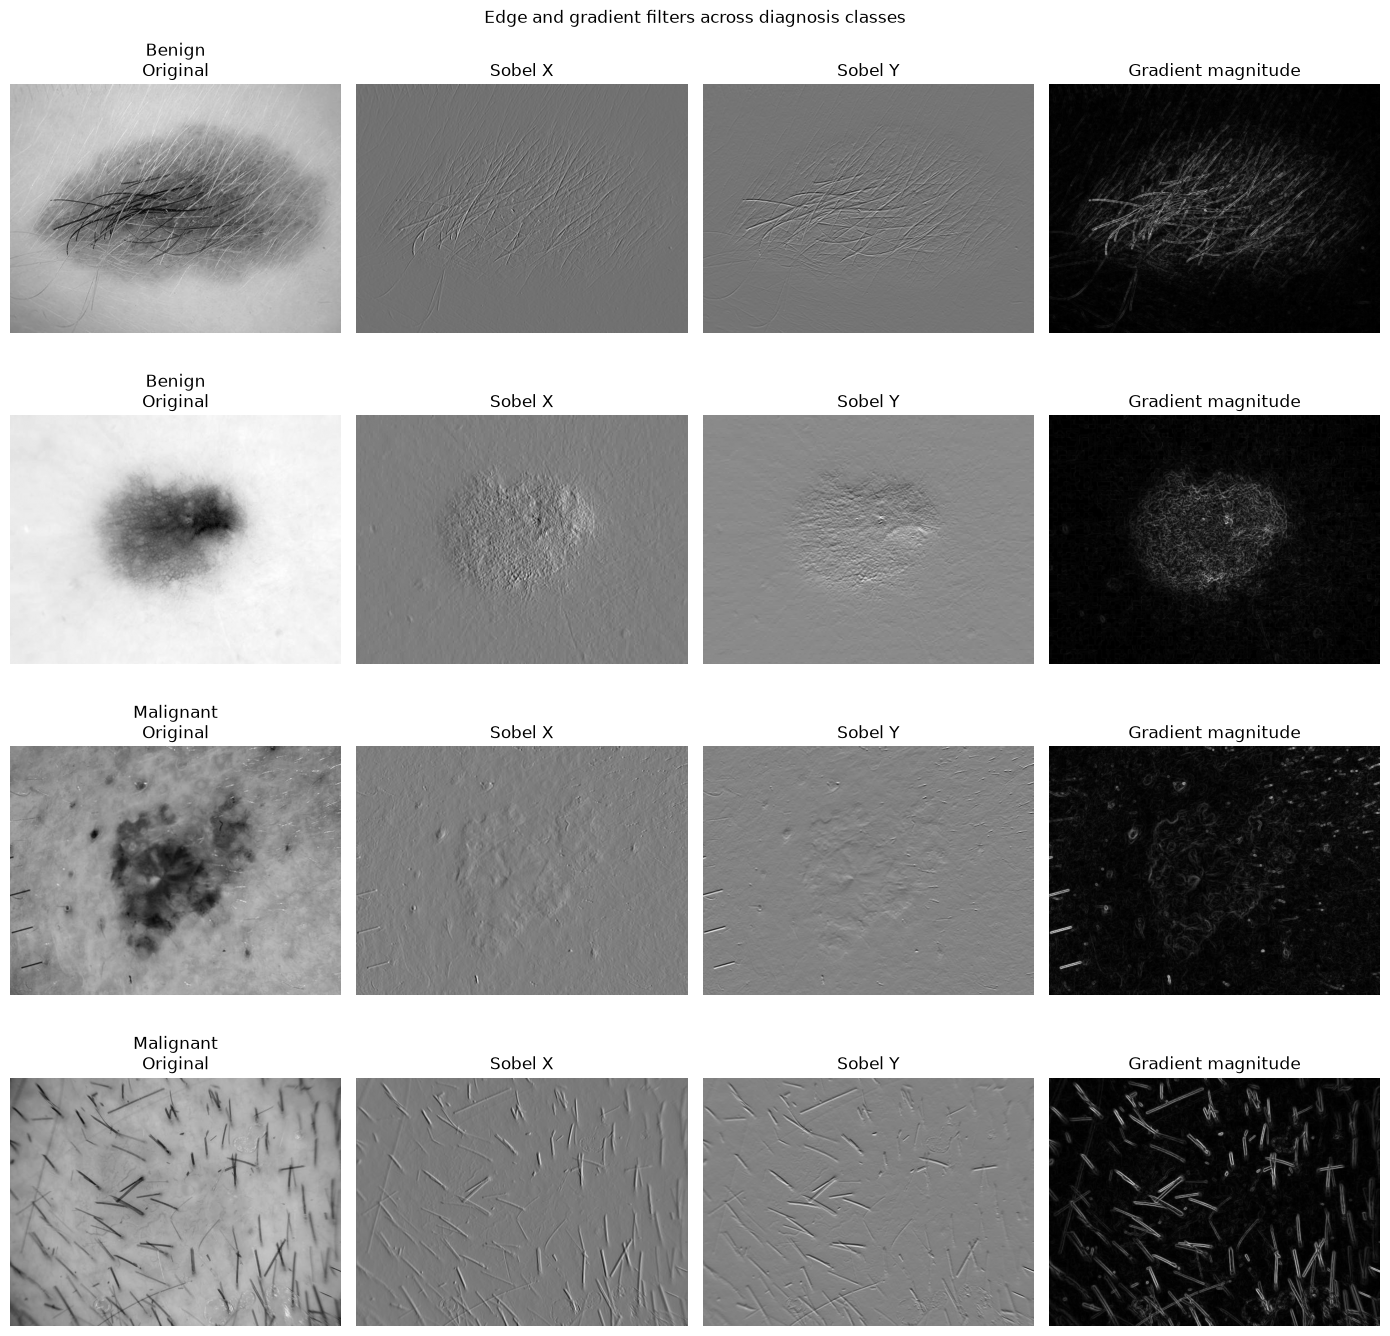

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, (_, row) in enumerate(selected.iterrows()):
    image_path = IMAGE_DIR / f"{row['derm_id']}.jpg"
    image = np.array(Image.open(image_path).convert("L")) / 255.0

    sobel_x = ndimage.sobel(image, axis=1)
    sobel_y = ndimage.sobel(image, axis=0)
    gradient = np.hypot(sobel_x, sobel_y)

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title(f"{row['diagnosis_1']}\nOriginal")

    axes[i, 1].imshow(sobel_x, cmap="gray")
    axes[i, 1].set_title("Sobel X")

    axes[i, 2].imshow(sobel_y, cmap="gray")
    axes[i, 2].set_title("Sobel Y")

    axes[i, 3].imshow(gradient, cmap="gray")
    axes[i, 3].set_title("Gradient magnitude")

    for ax in axes[i]:
        ax.axis("off")

plt.suptitle("Edge and gradient filters across diagnosis classes")
plt.tight_layout()
plt.show()

## 2. Gaussian blur

The `sigma` parameter of `scipy.ndimage.gaussian_filter` controls the standard deviation of the Gaussian kernel. Increasing sigma increases the amount of smoothing, so fine details and textures are progressively reduced.

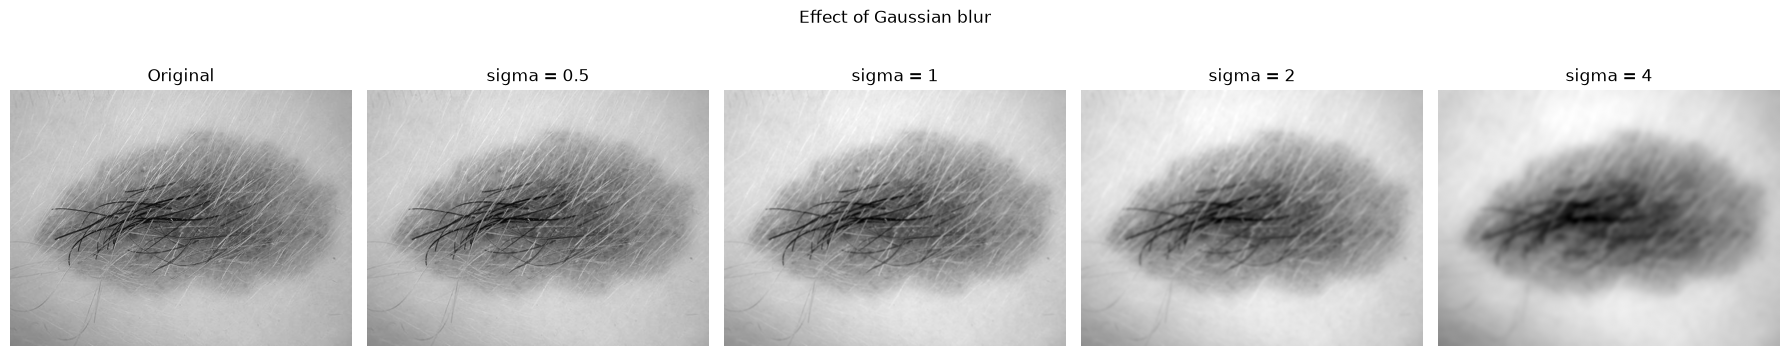

In [11]:
# Use the first selected image for the Gaussian blur experiment
row = selected.iloc[0]
image_path = IMAGE_DIR / f"{row['derm_id']}.jpg"
image_gray = np.array(Image.open(image_path).convert("L")) / 255.0

sigma_values = [0.5, 1, 2, 4]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, sigma in zip(axes[1:], sigma_values):
    blurred = ndimage.gaussian_filter(image_gray, sigma=sigma)
    ax.imshow(blurred, cmap="gray")
    ax.set_title(f"sigma = {sigma}")
    ax.axis("off")

plt.suptitle("Effect of Gaussian blur")
plt.tight_layout()
plt.show()

### Observation

As sigma increases, the image becomes progressively smoother. At low sigma, most lesion boundaries and fine textures remain visible. At higher sigma, small structures and fine textures are increasingly blurred, while larger-scale shapes remain visible. Therefore, sigma controls the strength/spatial scale of the smoothing.

## 3. Canny edge detection

Canny is a multi-stage edge detector. It first reduces noise with Gaussian smoothing, computes image gradients, thins candidate edges using non-maximum suppression, and then uses two thresholds with hysteresis to keep connected strong edges.

In [12]:
def non_maximum_suppression(magnitude, angle):
    """Thin gradient responses to local maxima."""
    rows, cols = magnitude.shape
    result = np.zeros_like(magnitude)

    angle = angle % 180

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            direction = angle[i, j]

            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                q = magnitude[i, j + 1]
                r = magnitude[i, j - 1]
            elif 22.5 <= direction < 67.5:
                q = magnitude[i + 1, j - 1]
                r = magnitude[i - 1, j + 1]
            elif 67.5 <= direction < 112.5:
                q = magnitude[i + 1, j]
                r = magnitude[i - 1, j]
            else:
                q = magnitude[i - 1, j - 1]
                r = magnitude[i + 1, j + 1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                result[i, j] = magnitude[i, j]

    return result


def hysteresis_threshold(image, low_ratio=0.10, high_ratio=0.20):
    """Keep strong edges and weak edges connected to strong edges."""
    high = image.max() * high_ratio
    low = image.max() * low_ratio

    strong = image >= high
    weak = (image >= low) & ~strong

    result = strong.copy()

    changed = True
    while changed:
        connected = ndimage.binary_dilation(result) & weak
        new_edges = connected & ~result
        result |= new_edges
        changed = np.any(new_edges)

    return result


def canny_custom(image, sigma=1.0):
    """Simplified Canny edge detector implemented with NumPy/SciPy."""
    smoothed = ndimage.gaussian_filter(image, sigma=sigma)

    sobel_x = ndimage.sobel(smoothed, axis=1)
    sobel_y = ndimage.sobel(smoothed, axis=0)

    magnitude = np.hypot(sobel_x, sobel_y)
    angle = np.degrees(np.arctan2(sobel_y, sobel_x))

    thinned = non_maximum_suppression(magnitude, angle)
    edges = hysteresis_threshold(thinned)

    return edges

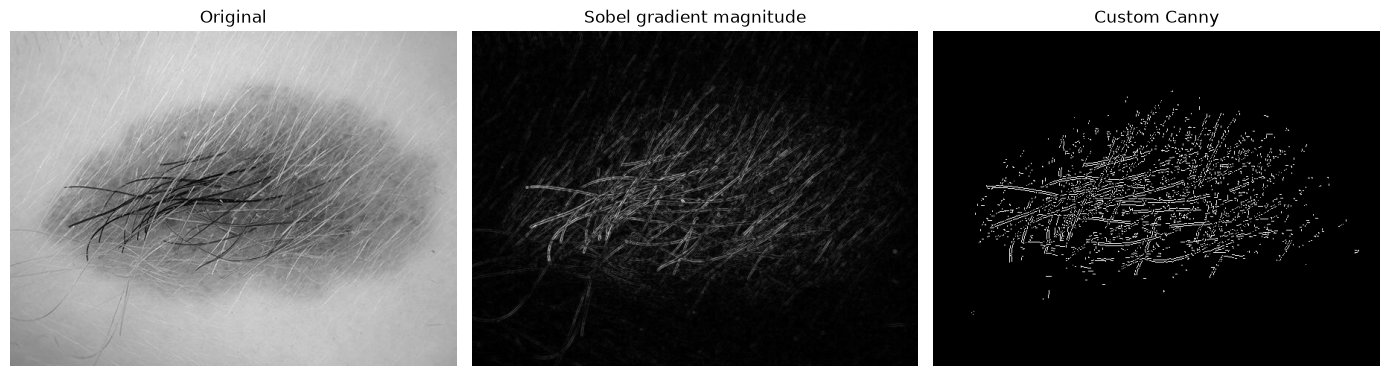

In [13]:
# Apply custom Canny and Sobel to the same image
canny_edges = canny_custom(image_gray, sigma=1.0)

sobel_x = ndimage.sobel(image_gray, axis=1)
sobel_y = ndimage.sobel(image_gray, axis=0)
sobel_magnitude = np.hypot(sobel_x, sobel_y)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sobel_magnitude, cmap="gray")
axes[1].set_title("Sobel gradient magnitude")
axes[1].axis("off")

axes[2].imshow(canny_edges, cmap="gray")
axes[2].set_title("Custom Canny")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Canny vs Sobel

The Sobel result shows the strength of local intensity gradients, so it contains both strong and weaker edge responses and can appear thicker or less selective. The Canny result is more selective and produces thinner, cleaner edge structures because it includes non-maximum suppression and hysteresis thresholding. In this image, Canny therefore gives a more clearly defined edge map than the raw Sobel gradient magnitude.

## References

- SciPy `gaussian_filter`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html
- scikit-image Canny edge detector: https://scikit-image.org/docs/stable/api/skimage.feature.html